In [38]:
!pip install scikit-fuzzy

In [90]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import jaccard_score
import skfuzzy as fuzz
from scipy.ndimage import binary_erosion, binary_dilation
from scipy.spatial.distance import directed_hausdorff

In [91]:
base_path = "/kaggle/input/datasets/inhvnnhn/krd-wbc-dataset/KRD WBC Dataset"

img_dir  = os.path.join(base_path, "train/images")
mask_dir = os.path.join(base_path, "train/mask")

image_files = sorted(os.listdir(img_dir))
img_name = image_files[0]  # picks image1.jpg

img_path  = os.path.join(img_dir, img_name)
mask_path = os.path.join(mask_dir, img_name)
img = cv2.imread(img_path)
gt_mask = cv2.imread(mask_path, 0)
img = cv2.GaussianBlur(img, (5, 5), 0)

gt_mask = cv2.resize(gt_mask, (256, 256))
img = cv2.resize(img, (256, 256))
gt_mask = (gt_mask > 127).astype(np.uint8)

In [92]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
pixels = lab.reshape((-1, 3)).astype(np.float32)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(pixels)
seg_kmeans = labels_kmeans.reshape(256, 256)
centers = kmeans.cluster_centers_

# Sort all 3 clusters by lightness: darkest=nucleus, mid=cytoplasm, brightest=background
sorted_clusters = np.argsort(centers[:, 0])


nucleus_cluster = sorted_clusters[0]
for cluster_id in sorted_clusters:
    candidate = (seg_kmeans == cluster_id).astype(np.uint8)
    if 0.05 < candidate.mean() < 0.40:
        nucleus_cluster = cluster_id
        break


cytoplasm_cluster = sorted_clusters[1]


background_cluster = sorted_clusters[2]

nucleus_mask_kmeans    = (seg_kmeans == nucleus_cluster).astype(np.uint8)
cytoplasm_mask_kmeans  = (seg_kmeans == cytoplasm_cluster).astype(np.uint8)
background_mask_kmeans = (seg_kmeans == background_cluster).astype(np.uint8)

In [93]:
data = pixels.T
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data, c=k, m=1.8, error=0.005, maxiter=1000
)

sorted_clusters_fcm = np.argsort(cntr[:, 0])


nucleus_cluster_fcm = sorted_clusters_fcm[0]
for cluster_id in sorted_clusters_fcm:
    candidate = (u[cluster_id].reshape(256, 256) > 0.5).astype(np.uint8)
    if 0.05 < candidate.mean() < 0.40:
        nucleus_cluster_fcm = cluster_id
        break


cytoplasm_cluster_fcm = sorted_clusters_fcm[1]

background_cluster_fcm = sorted_clusters_fcm[2]

hard_labels = np.argmax(u, axis=0)
seg_fcm = hard_labels.reshape(256,256)
nucleus_mask_fcm = (seg_fcm == nucleus_cluster_fcm).astype(np.uint8)
cytoplasm_mask_fcm  = (u[cytoplasm_cluster_fcm].reshape(256, 256) > 0.5).astype(np.uint8)
background_mask_fcm = (u[background_cluster_fcm].reshape(256, 256) > 0.5).astype(np.uint8)

In [94]:


def extract_boundary(mask):
    eroded = binary_erosion(mask)
    boundary = mask.astype(bool) & ~eroded
    return boundary.astype(np.uint8)

def hausdorff_distance(mask1, mask2):
    pts1 = np.argwhere(mask1)
    pts2 = np.argwhere(mask2)
    if len(pts1)==0 or len(pts2)==0:
        return float('inf')
    d1 = directed_hausdorff(pts1, pts2)[0]
    d2 = directed_hausdorff(pts2, pts1)[0]
    return max(d1,d2)

def boundary_f1_score(pred_boundary, gt_boundary, tolerance=2):

    struct = np.ones((2*tolerance+1, 2*tolerance+1))

    gt_dilated   = binary_dilation(gt_boundary,structure=struct)
    pred_dilated = binary_dilation(pred_boundary,structure=struct)

    tp_pred = np.sum(pred_boundary & gt_dilated)
    tp_gt   = np.sum(gt_boundary & pred_dilated)

    precision = tp_pred/(np.sum(pred_boundary)+1e-8)
    recall    = tp_gt/(np.sum(gt_boundary)+1e-8)

    f1 = 2*precision*recall/(precision+recall+1e-8)

    return precision, recall, f1




In [95]:

gt = gt_mask.flatten()


iou_kmeans = jaccard_score(gt, nucleus_mask_kmeans.flatten())
iou_fcm    = jaccard_score(gt, nucleus_mask_fcm.flatten())

gt_boundary  = extract_boundary(gt_mask)
km_boundary  = extract_boundary(nucleus_mask_kmeans)
fcm_boundary = extract_boundary(nucleus_mask_fcm)

hd_kmeans = hausdorff_distance(km_boundary, gt_boundary)
hd_fcm    = hausdorff_distance(fcm_boundary, gt_boundary)

prec_km,  rec_km,  f1_km  = boundary_f1_score(km_boundary,  gt_boundary)
prec_fcm, rec_fcm, f1_fcm = boundary_f1_score(fcm_boundary, gt_boundary)


km_cyto_boundary  = extract_boundary(cytoplasm_mask_kmeans)
fcm_cyto_boundary = extract_boundary(cytoplasm_mask_fcm)
hd_cyto = hausdorff_distance(km_cyto_boundary, fcm_cyto_boundary)

print("=" * 60)
print("         NUCLEUS SEGMENTATION COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'K-Means':>12} {'FCM':>12}")
print("-" * 60)
print(f"{'IoU Score':<30} {iou_kmeans:>12.4f} {iou_fcm:>12.4f}")
print(f"{'Hausdorff Distance (px)':<30} {hd_kmeans:>12.4f} {hd_fcm:>12.4f}")
print(f"{'Boundary Precision':<30} {prec_km:>12.4f} {prec_fcm:>12.4f}")
print(f"{'Boundary Recall':<30} {rec_km:>12.4f} {rec_fcm:>12.4f}")
print(f"{'Boundary F1-Score':<30} {f1_km:>12.4f} {f1_fcm:>12.4f}")
print("=" * 60)
print(f"\nCytoplasm Boundary HD (KM vs FCM): {hd_cyto:.4f} px")

         NUCLEUS SEGMENTATION COMPARISON
Metric                              K-Means          FCM
------------------------------------------------------------
IoU Score                            0.7554       0.2069
Hausdorff Distance (px)            181.4663     207.0869
Boundary Precision                   0.3696       0.0374
Boundary Recall                      0.6196       0.7546
Boundary F1-Score                    0.4630       0.0713

Cytoplasm Boundary HD (KM vs FCM): 16.0312 px


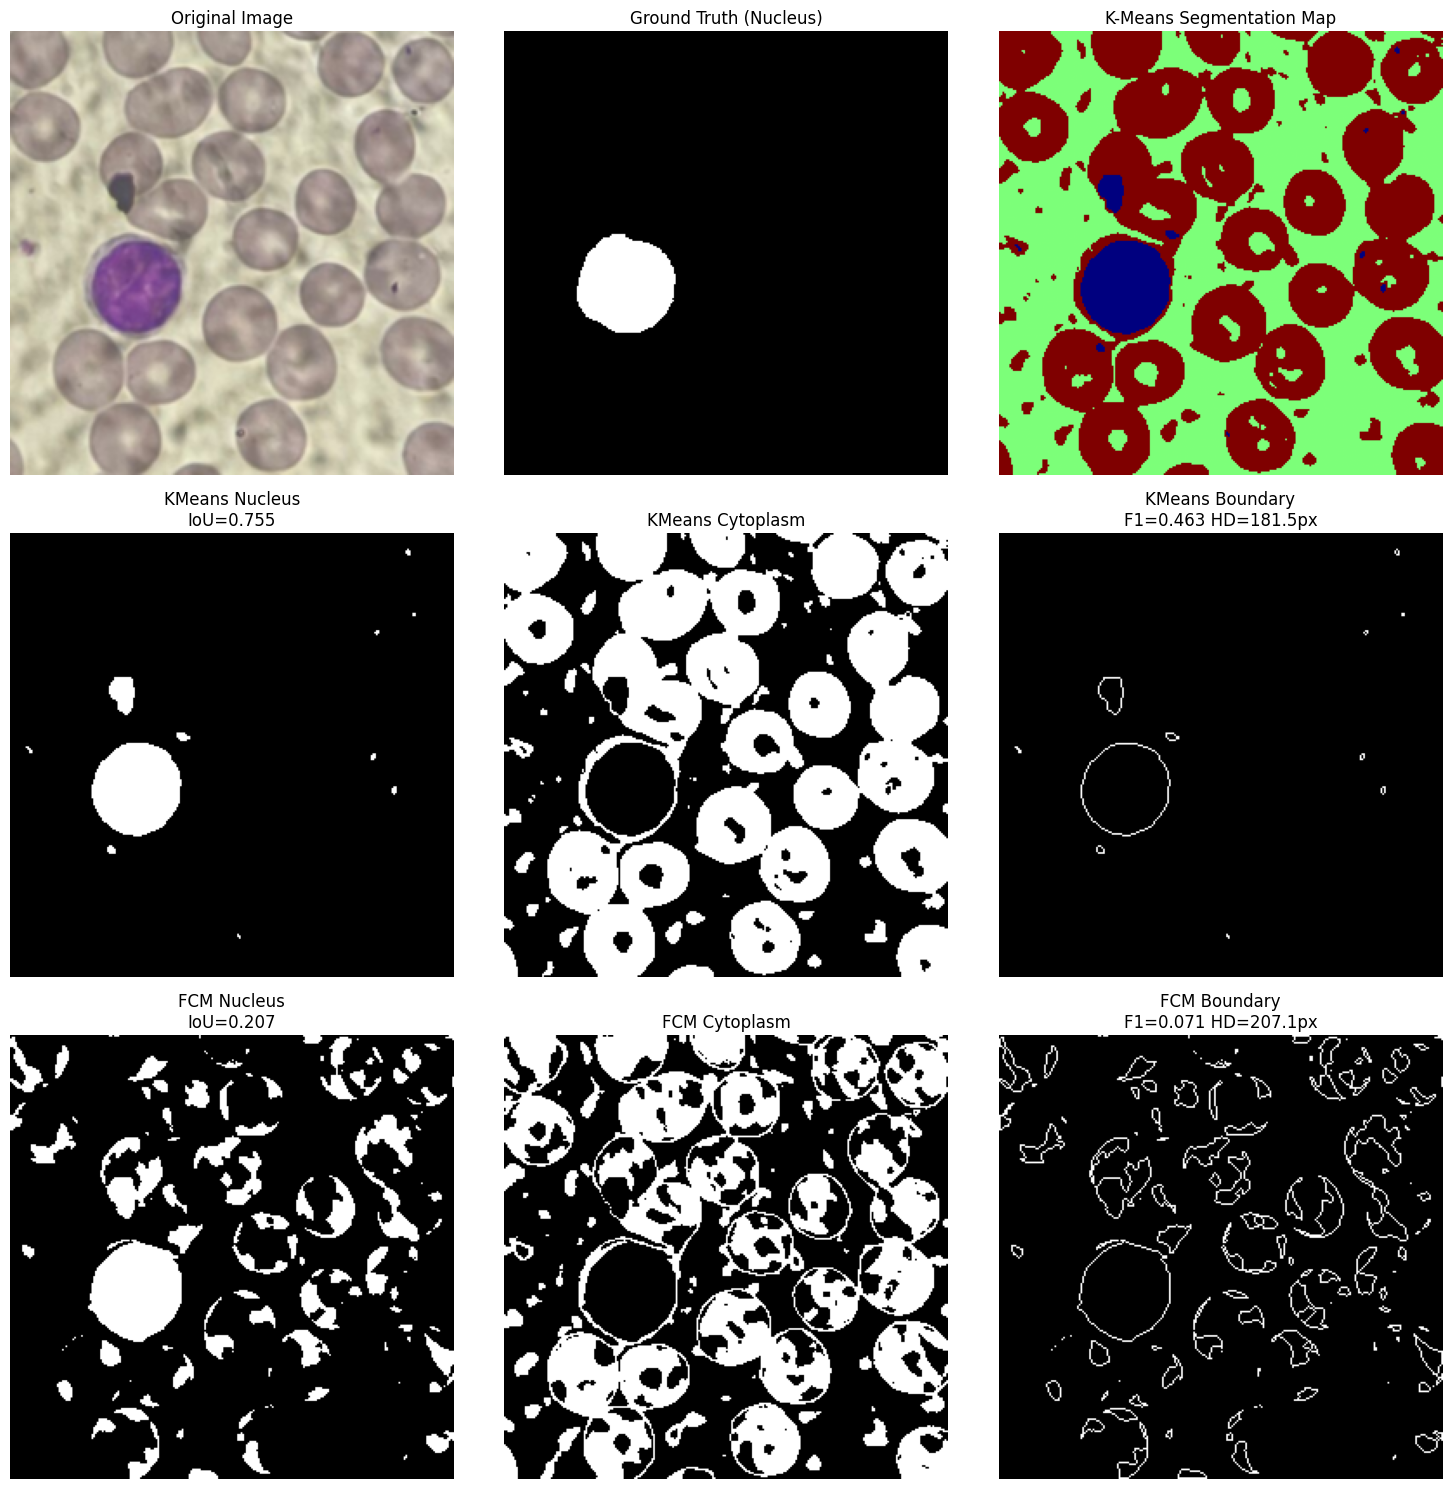

In [89]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Row 1: Original + GT + Segmentation maps
axes[0,0].imshow(img_rgb);                        axes[0,0].set_title("Original Image")
axes[0,1].imshow(gt_mask, cmap='gray');            axes[0,1].set_title("Ground Truth (Nucleus)")
axes[0,2].imshow(seg_kmeans, cmap='jet');          axes[0,2].set_title("K-Means Segmentation Map")

# Row 2: K-Means masks
axes[1,0].imshow(nucleus_mask_kmeans, cmap='gray');   axes[1,0].set_title(f"KMeans Nucleus\nIoU={iou_kmeans:.3f}")
axes[1,1].imshow(cytoplasm_mask_kmeans, cmap='gray'); axes[1,1].set_title("KMeans Cytoplasm")
axes[1,2].imshow(km_boundary, cmap='gray');           axes[1,2].set_title(f"KMeans Boundary\nF1={f1_km:.3f} HD={hd_kmeans:.1f}px")

# Row 3: FCM masks
axes[2,0].imshow(nucleus_mask_fcm, cmap='gray');      axes[2,0].set_title(f"FCM Nucleus\nIoU={iou_fcm:.3f}")
axes[2,1].imshow(cytoplasm_mask_fcm, cmap='gray');    axes[2,1].set_title("FCM Cytoplasm")
axes[2,2].imshow(fcm_boundary, cmap='gray');          axes[2,2].set_title(f"FCM Boundary\nF1={f1_fcm:.3f} HD={hd_fcm:.1f}px")

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.show()